<a href="https://colab.research.google.com/github/PrishmaMohun/Anomaly-Detection-Robbery/blob/main/Anomaly_Detection_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!nvidia-smi  # optional: check GPU

import os, zipfile, glob, shutil
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

Wed Apr 22 14:56:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install kaggle --quiet

import json, os
os.environ['KAGGLE_USERNAME'] = "YOUR_USERNAME"
os.environ['KAGGLE_KEY'] = "YOUR_KEY"

!kaggle datasets download -d simonphall/ucf-crime-images -p /content/ucf_images
!unzip -q /content/ucf_images/ucf-crime-images.zip -d /content/ucf_images

Dataset URL: https://www.kaggle.com/datasets/simonphall/ucf-crime-images
License(s): CC0-1.0
100% 170M/170M [00:12<00:00, 14.3MB/s]



In [5]:
!find /content/ucf_images -maxdepth 3 -type d | head -40

/content/ucf_images
/content/ucf_images/UCF Image Dataset
/content/ucf_images/UCF Image Dataset/UCF Image Dataset


In [6]:
base_dir = Path("/content/data")
for split in ["train", "val"]:
    for cls in ["Burglary", "Normal"]:
        (base_dir / split / cls).mkdir(parents=True, exist_ok=True)

In [7]:
burglary_src = Path("/content/ucf_images/.../Burglary")  # TODO: set real path
burglary_imgs = sorted(list(burglary_src.glob("*.jpg")))  # or *.png

len(burglary_imgs)

0

In [8]:
np.random.seed(42)
np.random.shuffle(burglary_imgs)

val_ratio = 0.2
val_size = int(len(burglary_imgs) * val_ratio)

val_burglary = burglary_imgs[:val_size]
train_burglary = burglary_imgs[val_size:]

for img_path in train_burglary:
    shutil.copy(img_path, base_dir / "train" / "Burglary" / img_path.name)

for img_path in val_burglary:
    shutil.copy(img_path, base_dir / "val" / "Burglary" / img_path.name)

In [9]:
normal_out_dir = Path("/content/ucf_images/UCF Image Dataset/UCF Image Dataset")
normal_imgs = sorted(list(normal_out_dir.glob("*.jpg")) + list(normal_out_dir.glob("*.png")))
np.random.shuffle(normal_imgs)

val_size_norm = int(len(normal_imgs) * val_ratio)
val_normal = normal_imgs[:val_size_norm]
train_normal = normal_imgs[val_size_norm:]

for img_path in train_normal:
    shutil.copy(img_path, base_dir / "train" / "Normal" / img_path.name)

for img_path in val_normal:
    shutil.copy(img_path, base_dir / "val" / "Normal" / img_path.name)

In [10]:
normal_imgs = sorted(list(normal_out_dir.glob("*.jpg")))
np.random.shuffle(normal_imgs)

val_size_norm = int(len(normal_imgs) * val_ratio)
val_normal = normal_imgs[:val_size_norm]
train_normal = normal_imgs[val_size_norm:]

for img_path in train_normal:
    shutil.copy(img_path, base_dir / "train" / "Normal" / img_path.name)

for img_path in val_normal:
    shutil.copy(img_path, base_dir / "val" / "Normal" / img_path.name)

In [11]:
!pip install tensorflow==2.15.0 --quiet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir / "train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir / "val",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1024).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Found 152 files belonging to 2 classes.
Found 37 files belonging to 2 classes.


In [12]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=img_size + (3,)
)
base_model.trainable = False  # freeze for transfer learning

inputs = keras.Input(shape=img_size + (3,))
x = tf.keras.applications.resnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.1579 - auc: 0.0000e+00 - loss: 1.6387 - val_accuracy: 0.1081 - val_auc: 0.0000e+00 - val_loss: 1.3490
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 407ms/step - accuracy: 0.2763 - auc: 0.0000e+00 - loss: 1.2923 - val_accuracy: 0.2432 - val_auc: 0.0000e+00 - val_loss: 1.0353
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 403ms/step - accuracy: 0.4013 - auc: 0.0000e+00 - loss: 0.9220 - val_accuracy: 0.5135 - val_auc: 0.0000e+00 - val_loss: 0.7791
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 397ms/step - accuracy: 0.5197 - auc: 0.0000e+00 - loss: 0.7639 - val_accuracy: 0.6216 - val_auc: 0.0000e+00 - val_loss: 0.5804
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step - accuracy: 0.6645 - auc: 0.0000e+00 - loss: 0.6174 - val_accuracy: 0.8108 - val_auc: 0.0000e+00 - val_loss: 0.4315
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 520ms/step - accuracy: 0.7566 - auc: 0.0000e+00 - loss: 0.4844 - val_accuracy: 0.9189 - val_auc: 0.0000e+00 - val_loss: 0.3244
Epoch 

In [14]:
import cv2

def predict_video(video_path, model, threshold=0.5, stride=5):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    burglary_frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % stride == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, img_size)
            x = np.expand_dims(frame_resized, axis=0).astype("float32")
            prob = float(model.predict(x, verbose=0)[0][0])
            if prob >= threshold:
                burglary_frames.append((frame_idx, prob))
        frame_idx += 1

    cap.release()
    return burglary_frames

burglary_frames = predict_video("/content/test_cctv.mp4", model)
print(burglary_frames[:10])

[]


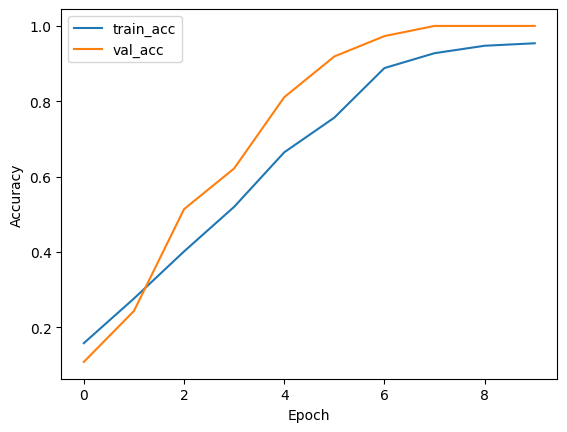

In [15]:
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


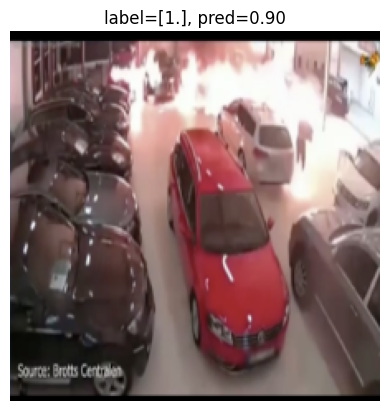

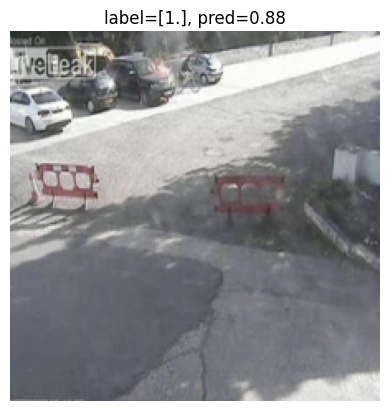

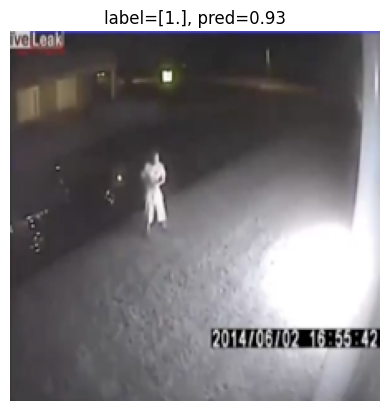

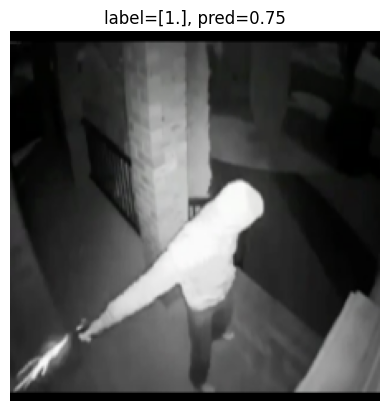

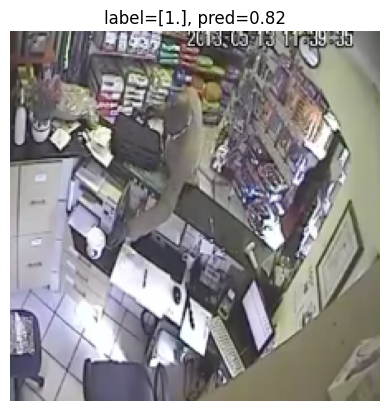

In [16]:
val_normal_batch = next(iter(val_ds))
images, labels = val_normal_batch

preds = model.predict(images)
for i in range(5):
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"label={labels[i].numpy()}, pred={preds[i][0]:.2f}")
    plt.axis("off")
    plt.show()

In [17]:
!find /content/ucf_images -maxdepth 3 -type d

/content/ucf_images
/content/ucf_images/UCF Image Dataset
/content/ucf_images/UCF Image Dataset/UCF Image Dataset


In [18]:
train_root = Path("/content/ucf_images/train")   # adjust based on what you see
test_root  = Path("/content/ucf_images/test")    # optional

In [19]:
burglary_src = train_root / "Burglary"
normal_src   = train_root / "NormalVideos"

burglary_imgs = sorted(list(burglary_src.glob("*.png")))  # or *.jpg depending on dataset
normal_imgs   = sorted(list(normal_src.glob("*.png")))

print(len(burglary_imgs), len(normal_imgs))

0 0


In [20]:
max_per_class = 20000

np.random.seed(42)
np.random.shuffle(burglary_imgs)
np.random.shuffle(normal_imgs)

burglary_imgs = burglary_imgs[:max_per_class]
normal_imgs   = normal_imgs[:max_per_class]

In [21]:
val_ratio = 0.2
val_burg = int(len(burglary_imgs) * val_ratio)
val_norm = int(len(normal_imgs) * val_ratio)

train_burglary, val_burglary = burglary_imgs[val_burg:], burglary_imgs[:val_burg]
train_normal,   val_normal   = normal_imgs[val_norm:], normal_imgs[:val_norm]

for img_path in train_burglary:
    shutil.copy(img_path, base_dir / "train" / "Burglary" / img_path.name)
for img_path in val_burglary:
    shutil.copy(img_path, base_dir / "val" / "Burglary" / img_path.name)

for img_path in train_normal:
    shutil.copy(img_path, base_dir / "train" / "Normal" / img_path.name)
for img_path in val_normal:
    shutil.copy(img_path, base_dir / "val" / "Normal" / img_path.name)

In [24]:
for img_path in train_normal:   # use train_normal instead of train_normal_gif
    shutil.copy(img_path, base_dir / "train" / "Normal" / img_path.name)

for img_path in val_normal:     # use val_normal instead of val_normal_gif
    shutil.copy(img_path, base_dir / "val" / "Normal" / img_path.name)

In [25]:
def anomaly_score(prob_burglary):
    # 0 for perfectly normal, 1 for highly anomalous
    return prob_burglary

In [26]:
def predict_video_with_score(video_path, model, threshold=0.5, stride=5, window=10):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    scores = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % stride == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, img_size)
            x = np.expand_dims(frame_resized, axis=0).astype("float32")
            prob = float(model.predict(x, verbose=0)[0][0])
            scores.append((frame_idx, prob))
        frame_idx += 1

    cap.release()

    anomaly_frames = []
    for i in range(len(scores)):
        start = max(0, i - window + 1)
        window_scores = [s[1] for s in scores[start:i+1]]
        avg_score = np.mean(window_scores)
        if avg_score >= threshold:
            anomaly_frames.append((scores[i][0], avg_score))

    return scores, anomaly_frames